In [4]:
import numpy as np  # Linear algebra 
import pandas as pd # Data processing 
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("wine_data.csv",header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [6]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])
df.sample(3)

,0,1,2
134,3,12.51,1.24
102,2,12.34,2.45
46,1,14.38,3.59


In [7]:
df.columns=['Class Label','Alcohol','Malic acid']
df.sample(5)

,Class Label,Alcohol,Malic acid
64,2,12.17,1.45
158,3,14.34,1.68
131,3,12.88,2.99
156,3,13.84,4.12
49,1,13.94,1.73


<Axes: xlabel='Alcohol', ylabel='Density'>

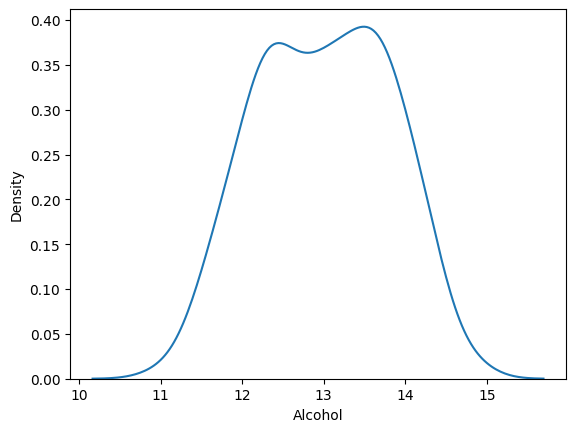

In [8]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

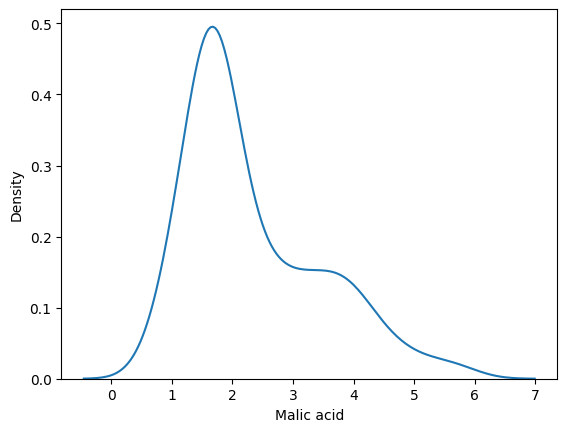

In [9]:

sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

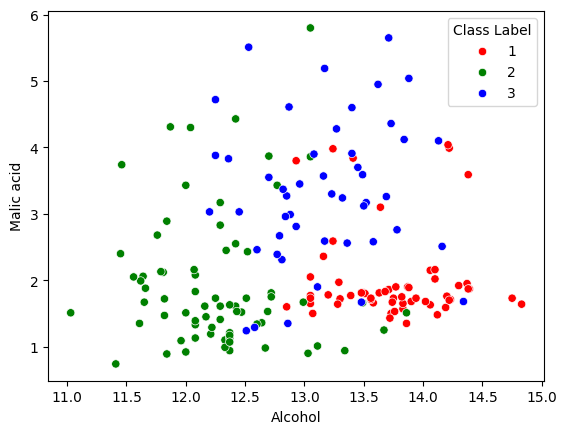

In [20]:
color_dict = {1:'red',2:'green',3:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class Label'],palette=color_dict)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class Label',axis=1),df['Class Label'],test_size=0.3,random_state=43)

X_train.shape,X_test.shape

((124, 2), (54, 2))

In [12]:
from sklearn .preprocessing import MinMaxScaler
scalar = MinMaxScaler()

#Fit the scalar to the train set,it will learn the parameters 
scalar.fit(X_train)

# transform train and test sets
X_train_scale = scalar.transform(X_train)
X_test_scale = scalar.transform(X_test)
# Now these X_train_scale and X_test_scale are in numpy array format we need to convert it into pandas dataframe 

In [13]:
X_train_scale = pd.DataFrame(X_train_scale,columns=X_train.columns)
X_test_scale = pd.DataFrame(X_test_scale,columns=X_test.columns)


In [14]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,12.9,2.3
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,12.9,1.8
75%,13.6,2.9
max,14.8,5.8


In [15]:
np.round(X_train_scale.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


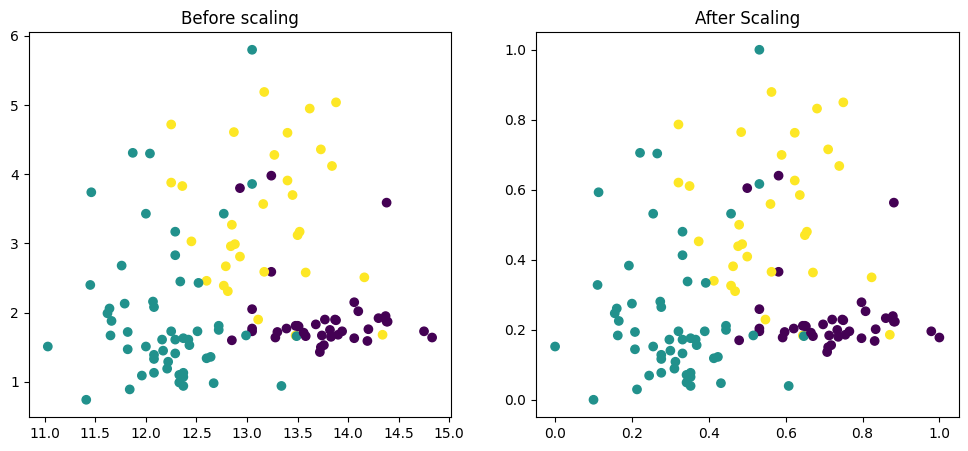

In [16]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Before scaling")
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'],c=y_train)

ax2.scatter(X_train_scale['Alcohol'], X_train_scale['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

# There is no difference after and before scaling instead of scaling 

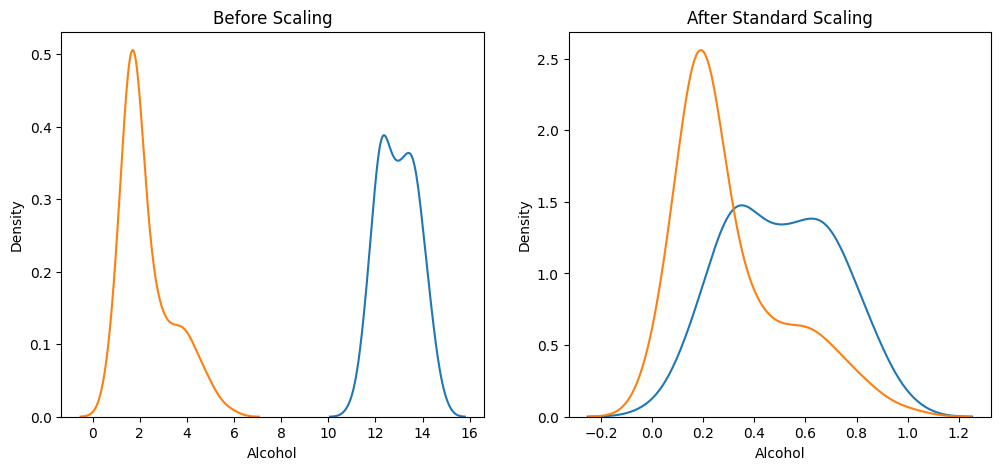

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scale['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scale['Malic acid'], ax=ax2)

plt.show()


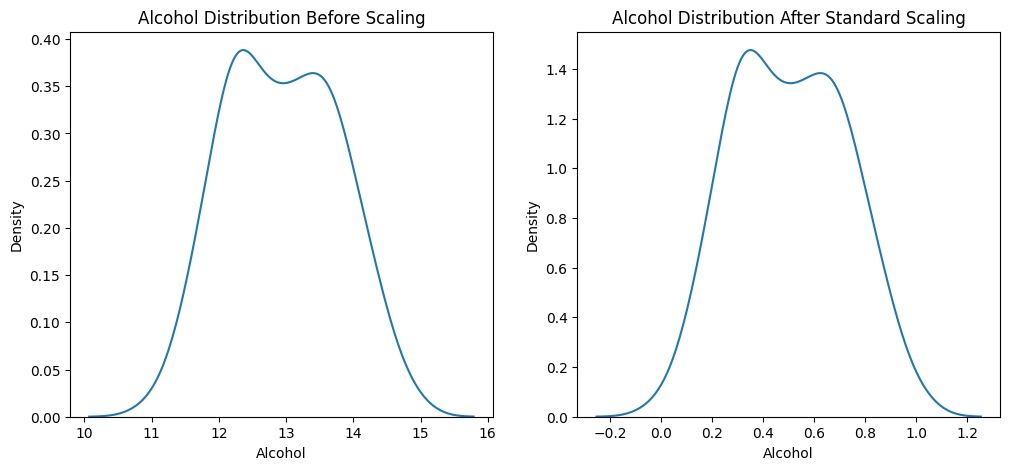

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scale['Alcohol'], ax=ax2)
plt.show()

# there is no difference before and after scaling 

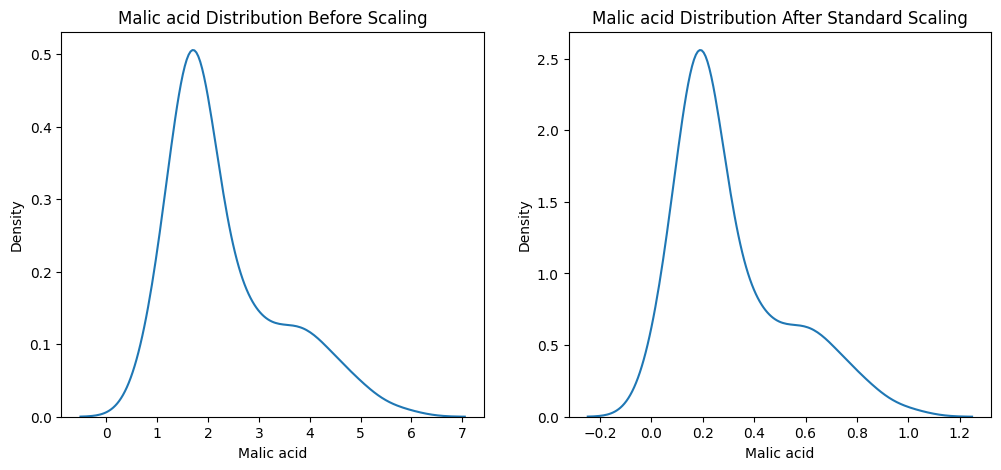

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scale['Malic acid'], ax=ax2)
plt.show()

# there is no difference before and after scaling 